In [87]:
import numpy as np
import pandas as pd
import openpyxl


In [88]:
aml_fraud_customer_profiling = pd.read_csv("data/aml_fraud_customer_profiling.csv")

In [89]:
aml_fraud_customer_profiling.Risk_Label.value_counts(dropna=False)


Risk_Label
Low_Risk     1400
High_Risk     600
Name: count, dtype: int64

In [90]:
aml_fraud_customer_profiling2 = aml_fraud_customer_profiling.copy()

Top features by |correlation| with Risk_Target:
Composite_Risk_Score          0.788194
Volume_x_CountryRisk          0.622756
Country_Risk_Score            0.578347
Country_Risk_Score_Squared    0.574695
Country_Risk_Flag             0.551247
Amount_x_CountryRisk          0.466767
Name: Risk_Target, dtype: float64

Best feature used for simple sigmoid view: Composite_Risk_Score
Sigmoid: p = 1 / (1 + exp(-(-10.4436 + 17.1498*Composite_Risk_Score)))
Decision boundary (Composite_Risk_Score at p=0.5): 0.6090


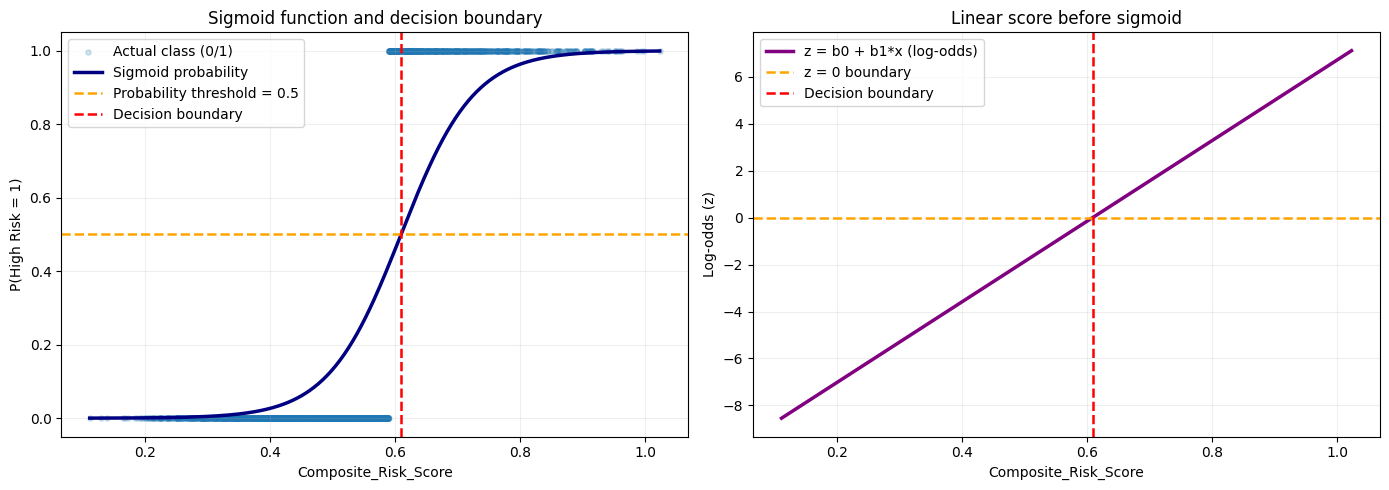


How this helps classification:
- The model first computes a linear score z = b0 + b1*x.
- Sigmoid converts z to probability between 0 and 1.
- If probability >= 0.5, classify as High_Risk (1), otherwise Low_Risk (0).
- The vertical line is the exact feature value where prediction flips class.


In [91]:
from sklearn.linear_model import LogisticRegression

# Select useful numeric features for AML risk classification
target = "Risk_Target"
num_cols = aml_fraud_customer_profiling2.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target]

corr = aml_fraud_customer_profiling2[num_cols + [target]].corr()[target].drop(target)
top_features_aml = corr.abs().sort_values(ascending=False).head(6).index.tolist()

print("Top features by |correlation| with Risk_Target:")
print(corr.loc[top_features_aml].sort_values(key=np.abs, ascending=False))

# Use the single strongest feature for a simple sigmoid explanation plot
best_feature = top_features_aml[0]
X = aml_fraud_customer_profiling2[[best_feature]].values
y = aml_fraud_customer_profiling2[target].values

import matplotlib.pyplot as plt

model = LogisticRegression()
model.fit(X, y)

# Sigmoid equation:
# p(y=1|x) = 1 / (1 + exp(-(b0 + b1*x)))
b0 = model.intercept_[0]
b1 = model.coef_[0, 0]

x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
p_grid = model.predict_proba(x_grid)[:, 1]
z_grid = b0 + b1 * x_grid.ravel()

# Decision boundary for p=0.5  <=>  z=0
decision_boundary_x = -b0 / b1 if b1 != 0 else np.nan

print(f"\nBest feature used for simple sigmoid view: {best_feature}")
print(f"Sigmoid: p = 1 / (1 + exp(-({b0:.4f} + {b1:.4f}*{best_feature})))")
print(f"Decision boundary ({best_feature} at p=0.5): {decision_boundary_x:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sigmoid probabilities + threshold and boundary lines
ax[0].scatter(
    X.ravel(), y, alpha=0.2, s=14, label="Actual class (0/1)"
)
ax[0].plot(x_grid, p_grid, color="navy", lw=2.5, label="Sigmoid probability")
ax[0].axhline(0.5, color="orange", ls="--", lw=1.8, label="Probability threshold = 0.5")
ax[0].axvline(decision_boundary_x, color="red", ls="--", lw=1.8, label="Decision boundary")
ax[0].set_xlabel(best_feature)
ax[0].set_ylabel("P(High Risk = 1)")
ax[0].set_title("Sigmoid function and decision boundary")
ax[0].legend(loc="best")
ax[0].grid(alpha=0.2)

# Plot 2: Linear score (log-odds) with boundary z=0
ax[1].plot(x_grid, z_grid, color="purple", lw=2.5, label="z = b0 + b1*x (log-odds)")
ax[1].axhline(0, color="orange", ls="--", lw=1.8, label="z = 0 boundary")
ax[1].axvline(decision_boundary_x, color="red", ls="--", lw=1.8, label="Decision boundary")
ax[1].set_xlabel(best_feature)
ax[1].set_ylabel("Log-odds (z)")
ax[1].set_title("Linear score before sigmoid")
ax[1].legend(loc="best")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(
    "\nHow this helps classification:\n"
    "- The model first computes a linear score z = b0 + b1*x.\n"
    "- Sigmoid converts z to probability between 0 and 1.\n"
    "- If probability >= 0.5, classify as High_Risk (1), otherwise Low_Risk (0).\n"
    "- The vertical line is the exact feature value where prediction flips class."
)

In [92]:
aml_fraud_customer_profiling2.head()

,Unique_Name,Country,Country_Risk_Score,Transaction_Amount,Transaction_Volume_30D,Transaction_Trend_30D,Previous_Banking_History_Score,Chargeback_Count_12M,Past_SAR_Flag,Account_Age_Days,...,Risk_Target,Risk_Label,Country_Risk_Flag,Composite_Risk_Score,Country_Risk_Score_Squared,Transaction_Amount_Cubed,History_Inverse_Squared,Amount_x_CountryRisk,Amount_x_Trend,Volume_x_CountryRisk
0,AML_Customer_00001,DE,0.17,4113.45,24,-0.190,77.47,2,0,2914,...,0,Low_Risk,0,0.290575,0.0289,69.6015,507.6009,699.29,-781.555,4.08
1,AML_Customer_00002,PK,0.55,4329.12,20,0.663,100.00,0,1,3091,...,0,Low_Risk,1,0.555063,0.3025,81.1332,0.0000,2381.02,2870.207,11.00
2,AML_Customer_00003,BR,0.40,7891.34,23,-0.051,41.04,2,1,3371,...,0,Low_Risk,0,0.513282,0.1600,491.4194,3476.2816,3156.54,-402.458,9.20
3,AML_Customer_00004,IN,0.35,14290.72,26,0.325,56.47,1,0,1640,...,1,High_Risk,0,0.618290,0.1225,2918.5177,1894.8609,5001.75,4644.484,9.10
4,AML_Customer_00005,UK,0.18,24675.96,18,-0.576,57.21,3,0,3519,...,0,Low_Risk,0,0.500040,0.0324,15025.2661,1830.9841,4441.67,-14213.353,3.24


In [93]:
# Volume_x_CountryRisk          
# Country_Risk_Score            
# Country_Risk_Score_Squared    
# Country_Risk_Flag            
# Amount_x_CountryRisk  

In [94]:
cols = [
    'Volume_x_CountryRisk',
    'Country_Risk_Score',
    'Country_Risk_Score_Squared',
    'Country_Risk_Flag',
    'Amount_x_CountryRisk'
]

df_aml_features = aml_fraud_customer_profiling2[cols].copy()
df_aml_features.head()

,Volume_x_CountryRisk,Country_Risk_Score,Country_Risk_Score_Squared,Country_Risk_Flag,Amount_x_CountryRisk
0,4.08,0.17,0.0289,0,699.29
1,11.00,0.55,0.3025,1,2381.02
2,9.20,0.40,0.1600,0,3156.54
3,9.10,0.35,0.1225,0,5001.75
4,3.24,0.18,0.0324,0,4441.67


In [95]:
# explain and simplify how this can be used o

In [96]:
# create a simplification and visual representation of logg loss, cost and Loss for classification models, especially in the context of logistic regression.

Using real target: Is_Suspicious
Features used: ['Transaction_Amount', 'Country_Amount_Interaction', 'Velocity_Risk', 'Num_Transactions_24h']
Average Cost (mean log loss): 0.0243

Formulas:
Loss_i = -(y_i*log(p_i) + (1-y_i)*log(1-p_i))
Cost   = (1/N) * Σ Loss_i


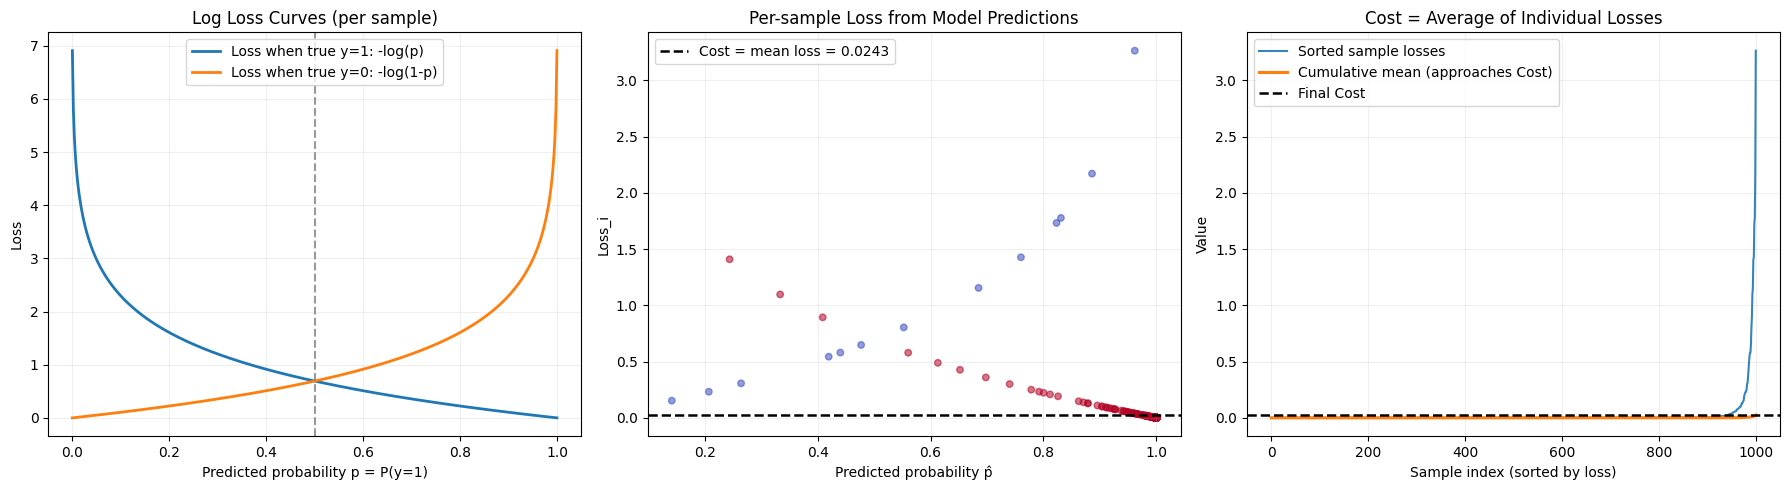

In [97]:
# Simplified visual explanation of Loss (per sample) vs Cost (average loss) for logistic regression

# 1) Pick an available dataframe and target
df_for_demo = df_logistic.copy() if "df_logistic" in globals() else df_imported.copy()
target_name = target_col if ("target_col" in globals() and target_col in df_for_demo.columns) else "Is_Suspicious"

# 2) Build y (fallback if single class, for teaching visualization)
y_raw = df_for_demo[target_name].astype(int).values
if np.unique(y_raw).size < 2:
    y_demo = (df_for_demo["Transaction_Amount"] > df_for_demo["Transaction_Amount"].median()).astype(int).values
    note = "Target had one class only, so demo labels were created from median(Transaction_Amount)."
else:
    y_demo = y_raw
    note = f"Using real target: {target_name}"

# 3) Select a few numeric features and fit logistic regression
candidate_features = [c for c in ["Transaction_Amount", "Country_Amount_Interaction", "Velocity_Risk", "Num_Transactions_24h"] if c in df_for_demo.columns]
X_demo = df_for_demo[candidate_features].values

demo_model = LogisticRegression(max_iter=1000)
demo_model.fit(X_demo, y_demo)

# Predicted probability for class 1
p_hat = demo_model.predict_proba(X_demo)[:, 1]

# 4) Per-sample log loss and cost (mean loss)
eps = 1e-15
p_safe = np.clip(p_hat, eps, 1 - eps)
sample_loss = -(y_demo * np.log(p_safe) + (1 - y_demo) * np.log(1 - p_safe))
cost = sample_loss.mean()

print(note)
print(f"Features used: {candidate_features}")
print(f"Average Cost (mean log loss): {cost:.4f}")
print(
    "\nFormulas:\n"
    "Loss_i = -(y_i*log(p_i) + (1-y_i)*log(1-p_i))\n"
    "Cost   = (1/N) * Σ Loss_i"
)

# 5) Visual representation
p_grid_demo = np.linspace(0.001, 0.999, 500)
loss_if_y1 = -np.log(p_grid_demo)       # true class = 1
loss_if_y0 = -np.log(1 - p_grid_demo)   # true class = 0

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# A) Theoretical log-loss shape
ax[0].plot(p_grid_demo, loss_if_y1, label="Loss when true y=1: -log(p)", lw=2)
ax[0].plot(p_grid_demo, loss_if_y0, label="Loss when true y=0: -log(1-p)", lw=2)
ax[0].axvline(0.5, ls="--", color="gray", alpha=0.8)
ax[0].set_title("Log Loss Curves (per sample)")
ax[0].set_xlabel("Predicted probability p = P(y=1)")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(alpha=0.2)

# B) Real sample losses from fitted model
ax[1].scatter(p_hat, sample_loss, c=y_demo, cmap="coolwarm", alpha=0.55, s=22)
ax[1].axhline(cost, color="black", ls="--", lw=1.8, label=f"Cost = mean loss = {cost:.4f}")
ax[1].set_title("Per-sample Loss from Model Predictions")
ax[1].set_xlabel("Predicted probability p̂")
ax[1].set_ylabel("Loss_i")
ax[1].legend()
ax[1].grid(alpha=0.2)

# C) From losses to cost (aggregation)
loss_sorted = np.sort(sample_loss)
cum_cost = np.cumsum(loss_sorted) / np.arange(1, len(loss_sorted) + 1)
ax[2].plot(loss_sorted, label="Sorted sample losses", alpha=0.9)
ax[2].plot(cum_cost, label="Cumulative mean (approaches Cost)", lw=2.2)
ax[2].axhline(cost, color="black", ls="--", lw=1.8, label="Final Cost")
ax[2].set_title("Cost = Average of Individual Losses")
ax[2].set_xlabel("Sample index (sorted by loss)")
ax[2].set_ylabel("Value")
ax[2].legend()
ax[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Feature used: Composite_Risk_Score
Final parameters -> w: 2.8842, b: -1.4547
Initial cost: 0.6931
Final cost:   0.1721


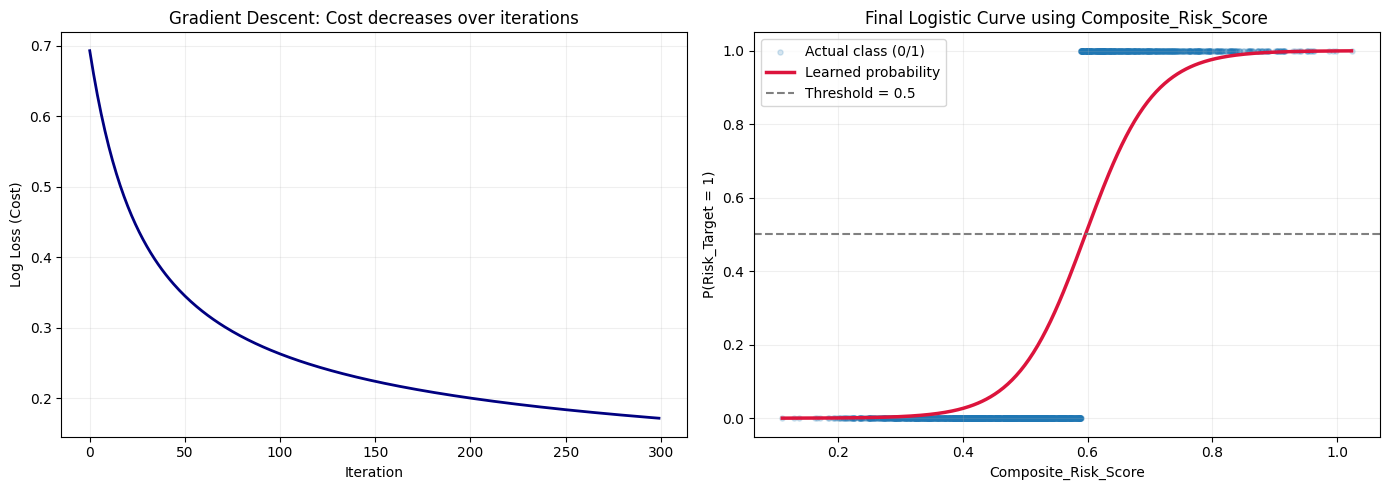


Simple intuition:
1) Start with random/zero parameters (w, b).
2) Predict probabilities with sigmoid.
3) Measure error using log loss (cost).
4) Compute gradients (direction to reduce cost).
5) Update w and b repeatedly.
6) Cost goes down, and the model separates classes better.


In [98]:
# Simplified gradient descent explanation for logistic regression (using your AML dataset)

# 1) Pick one strong feature and target from existing notebook variables
feature_gd = top_features_aml[0]  # e.g., 'Composite_Risk_Score'
df_gd = aml_fraud_customer_profiling2[[feature_gd, target]].dropna().copy()

X_raw = df_gd[feature_gd].values.astype(float)
y_gd = df_gd[target].values.astype(float)

# 2) Standardize feature for stable gradient descent
mu, sigma = X_raw.mean(), X_raw.std()
X = ((X_raw - mu) / sigma).reshape(-1, 1)

# 3) Logistic regression with manual gradient descent
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w, b = 0.0, 0.0
lr = 0.1
n_iter = 300
eps = 1e-12

cost_history = []
w_history = []
b_history = []
grad_norm_history = []

for i in range(n_iter):
    z = X.ravel() * w + b
    p = sigmoid(z)

    # Log loss (cost)
    p_safe = np.clip(p, eps, 1 - eps)
    cost = -np.mean(y_gd * np.log(p_safe) + (1 - y_gd) * np.log(1 - p_safe))

    # Gradients
    error = p - y_gd
    dw = np.mean(error * X.ravel())
    db = np.mean(error)

    # Parameter update (gradient descent step)
    w -= lr * dw
    b -= lr * db

    # Track learning
    cost_history.append(cost)
    w_history.append(w)
    b_history.append(b)
    grad_norm_history.append(np.sqrt(dw**2 + db**2))

print(f"Feature used: {feature_gd}")
print(f"Final parameters -> w: {w:.4f}, b: {b:.4f}")
print(f"Initial cost: {cost_history[0]:.4f}")
print(f"Final cost:   {cost_history[-1]:.4f}")

# 4) Visuals: cost reduction + final sigmoid curve
x_grid_orig = np.linspace(X_raw.min(), X_raw.max(), 400)
x_grid_std = (x_grid_orig - mu) / sigma
p_grid = sigmoid(w * x_grid_std + b)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# A) Cost over iterations (shows gradient descent learning)
ax[0].plot(cost_history, color="navy", lw=2)
ax[0].set_title("Gradient Descent: Cost decreases over iterations")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Log Loss (Cost)")
ax[0].grid(alpha=0.2)

# B) Final logistic curve on real feature scale
ax[1].scatter(X_raw, y_gd, alpha=0.18, s=14, label="Actual class (0/1)")
ax[1].plot(x_grid_orig, p_grid, color="crimson", lw=2.5, label="Learned probability")
ax[1].axhline(0.5, ls="--", color="gray", lw=1.5, label="Threshold = 0.5")
ax[1].set_title(f"Final Logistic Curve using {feature_gd}")
ax[1].set_xlabel(feature_gd)
ax[1].set_ylabel("P(Risk_Target = 1)")
ax[1].legend(loc="best")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(
    "\nSimple intuition:\n"
    "1) Start with random/zero parameters (w, b).\n"
    "2) Predict probabilities with sigmoid.\n"
    "3) Measure error using log loss (cost).\n"
    "4) Compute gradients (direction to reduce cost).\n"
    "5) Update w and b repeatedly.\n"
    "6) Cost goes down, and the model separates classes better."
)